In [48]:
from datasets import load_dataset,load_from_disk
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set()

In [31]:
IMDB_DATA  = 'stanfordnlp/imdb'
AMAZON_DATA = 'mteb/amazon_polarity'
HOTEL_DATA = 'enelpol/booking_com_reviews'
SENTIMENT_DATA = 'adilbekovich/Sentiment140Twitter'

# IMDB Dataset

In [4]:
imdb_data = load_dataset(IMDB_DATA)

In [5]:
print(imdb_data['train'][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [6]:
label_values = Counter(imdb_data['train']['label'])

<Axes: >

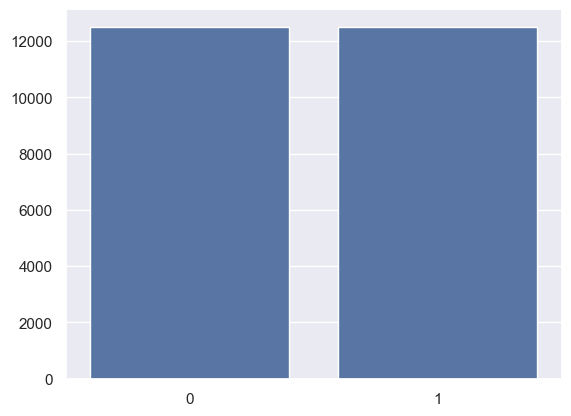

In [7]:
sns.barplot(data=label_values)


In [8]:
test_label_values = Counter(imdb_data['test']['label'])

<Axes: >

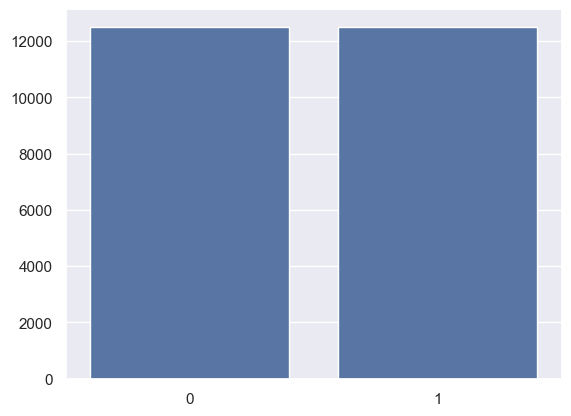

In [9]:
sns.barplot(test_label_values)

## Observations
1. The `imdb_data` is very balanced with 12500 training and 12500 testing rows.
2. Both the train and the test split have 50-50 positive and negative lables
3. We are going to merge them and then do a 70-30 split on them so that we can have a better training and testing data

# Amazon Dataset

In [10]:
amazon_data = load_dataset(AMAZON_DATA)

In [11]:
amazon_data['train'][10]

{'label': 0,
 'text': "The Worst!\n\nA complete waste of time. Typographical errors, poor grammar, and a totally pathetic plot add up to absolutely nothing. I'm embarrassed for this author and very disappointed I actually paid for this book.",
 'label_text': 'negative'}

In [12]:
amazon_label_counter = Counter(amazon_data['train']['label'])

In [13]:
amazon_label_counter

Counter({1: 1799998, 0: 1799996})

## Observations:
1. The `amazon_data` dataset is much more diverse but is well balanced
2. We have way more data in the amazon dataset than in the imdb dataset.
3. We are going to make sure that the number of training examples from all the datasets that we use are going to be the same

# Yelp Dataset

In [17]:
hotel_dataset = load_dataset(HOTEL_DATA)

In [19]:
hotel_dataset['train']

Dataset({
    features: ['Negative_Review', 'Positive_Review'],
    num_rows: 515738
})

## Obersvations
1. There are enough data that we can use to get the positive and negative reviews
2. We just need to make sure that we have the same number of reviews as we need them to be the best

# Financial Data

In [32]:
sentiment_data = load_dataset('adilbekovich/Sentiment140Twitter')

Generating test split: 100%|██████████| 240000/240000 [00:00<00:00, 1418850.04 examples/s]


<Axes: >

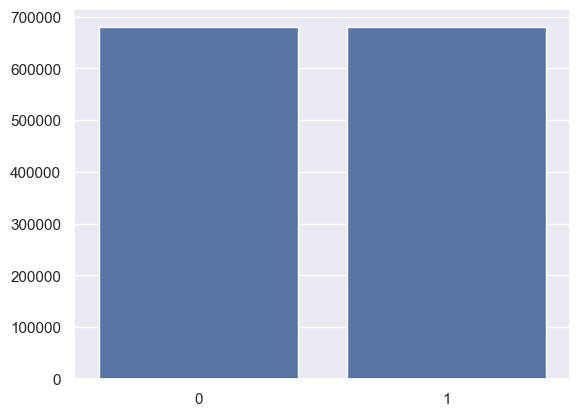

In [36]:
sentiment_data_counter = Counter(sentiment_data['train']['label'])
sns.barplot(sentiment_data_counter)

<Axes: >

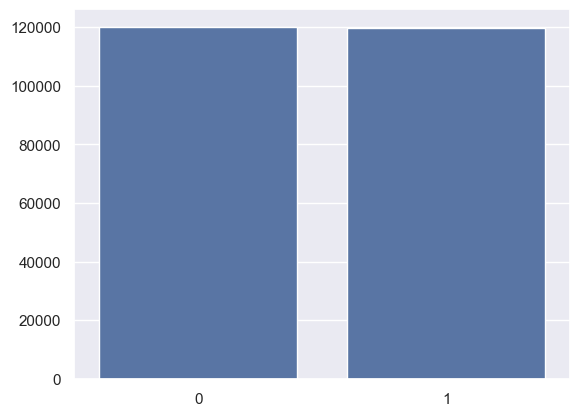

In [37]:
sentiment_data_counter = Counter(sentiment_data['test']['label'])
sns.barplot(sentiment_data_counter)

In [38]:
imdb_data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

# Final Verdict
1. We have dropped the use of FINANCIAL_DATA due to unavalibility of enough data to train the model
2. We will be using about 35000 rows for training and about 15000 rows for testing
3. This splits will be followed in the split section

In [39]:
imdb_data = load_dataset(IMDB_DATA,split='all')

In [40]:
imdb_data

Dataset({
    features: ['text', 'label'],
    num_rows: 100000
})

In [41]:
amazon_data

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'label_text'],
        num_rows: 3599994
    })
    test: Dataset({
        features: ['label', 'text', 'label_text'],
        num_rows: 400000
    })
})

In [43]:
class GetHotelData:
    '''
    This class is responsible for gathering IMDb data, selecting a random subset,
    splitting it, and storing it locally in a structured directory.
    '''
    def __init__(self):
        
        self.dataset_name = os.environ.get('HOTEL_DATA', 'hotel') 
        self.split_dataset = None
        
        self.output_dir = "hotel"

    def getData(self, subset_size=None):
        
        full_data = load_dataset(self.dataset_name, split='all')
        
        # If you want to select a random number of rows (e.g., 5000)
        if subset_size:
            full_data = full_data.shuffle(seed=42).select(range(subset_size))

        
        self.split_dataset = full_data.train_test_split(test_size=0.3, seed=42)

    def saveData(self):
        if self.split_dataset is None:
            print("No data found. Please run getData() first.")
            return

        # 1. Create the main 'imdb' directory if it doesn't exist
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            print(f"Created directory: {self.output_dir}")

        # 2. Print row counts
        print(f"Number of rows in the training set: {self.split_dataset['train'].num_rows}")
        print(f"Number of rows in the test set: {self.split_dataset['test'].num_rows}")

        # 3. Save train and test separately inside the 'imdb' folder
        train_path = os.path.join(self.output_dir, "train")
        test_path = os.path.join(self.output_dir, "test")

        self.split_dataset['train'].save_to_disk(train_path)
        self.split_dataset['test'].save_to_disk(test_path)

        print(f"Data successfully saved to {train_path} and {test_path}")


Generating train split: 1 examples [00:00, 201.98 examples/s]
Generating test split: 1 examples [00:00, 1131.15 examples/s]


In [53]:
hotel_data_train = load_from_disk('hotel/train')

In [55]:
amazon_data

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'label_text'],
        num_rows: 3599994
    })
    test: Dataset({
        features: ['label', 'text', 'label_text'],
        num_rows: 400000
    })
})